In [ ]:
# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *
from itertools import groupby
from sklearn import metrics
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns


# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

# Week 1: Cleaning and Understanding Data

## Uploading Data

In [ ]:
churn_data = Table().read_table("https://raw.githubusercontent.com/bon-pang/DS-capstone/main/BankChurners%5B1%5D.csv")
churn_data

CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691,777,11914,1.335,1144,42,1.625,0.061,9.3448e-05,0.99991
818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256,864,7392,1.541,1291,33,3.714,0.105,5.6861e-05,0.99994
713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418,0,3418,2.594,1887,20,2.333,0,2.1081e-05,0.99998
769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313,2517,796,1.405,1171,20,2.333,0.76,0.00013366,0.99987
709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716,0,4716,2.175,816,28,2.5,0,2.1676e-05,0.99998
713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010,1247,2763,1.376,1088,24,0.846,0.311,5.5077e-05,0.99994
810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516,2264,32252,1.975,1330,31,0.722,0.066,0.00012303,0.99988
818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081,1396,27685,2.204,1538,36,0.714,0.048,8.5795e-05,0.99991
710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352,2517,19835,3.355,1350,24,1.182,0.113,4.4796e-05,0.99996
719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656,1677,9979,1.524,1441,32,0.882,0.144,0.00030251,0.9997


In [ ]:
#removing their precalculated naive bayes classifier
churn_data = churn_data.drop(21,22)

In [ ]:
#changing our churn indicator to a boolean, 1 = churned, 0 = existing
def to_bool(status):
  if "Existing" in status:
    return False
  else:
    return True

def to_num(status):
  if "Existing" in status:
    return 0
  else:
    return 1

churn_bools = churn_data.apply(to_bool, "Attrition_Flag")
churn_nums = churn_data.apply(to_num, "Attrition_Flag")

churn_data = churn_data.with_columns("Churn Status", churn_bools, "Churn Num", churn_nums)
churn_data = churn_data.drop(0,1)
churn_data

Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn Status,Churn Num
45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691,777,11914,1.335,1144,42,1.625,0.061,False,0
49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256,864,7392,1.541,1291,33,3.714,0.105,False,0
51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418,0,3418,2.594,1887,20,2.333,0,False,0
40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313,2517,796,1.405,1171,20,2.333,0.76,False,0
40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716,0,4716,2.175,816,28,2.5,0,False,0
44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010,1247,2763,1.376,1088,24,0.846,0.311,False,0
51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516,2264,32252,1.975,1330,31,0.722,0.066,False,0
32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081,1396,27685,2.204,1538,36,0.714,0.048,False,0
37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352,2517,19835,3.355,1350,24,1.182,0.113,False,0
48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656,1677,9979,1.524,1441,32,0.882,0.144,False,0


When data is missing, it's logged as "Unknown", only in columns Education Level, Marital Status and Income Category

In [ ]:
np.mean(churn_data.where("Churn Status", are.equal_to(True)).column("Total_Revolving_Bal"))

672.82298709280883

# Week 2: Graphing and Visualization

## Variable Analysis

In [ ]:
churn_data.group("Churn Status")

Churn Status,count
False,8500
True,1627


In [ ]:
churn_data.group("Gender")

Gender,count
F,5358
M,4769


5

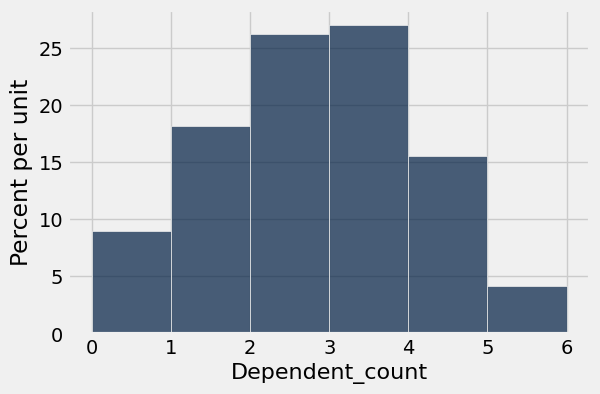

In [ ]:
churn_data.hist("Dependent_count", bins = np.arange(0,7))
max(churn_data.column("Dependent_count"))

In [ ]:
churn_data.num_rows

10127

In [ ]:
churn_data.select("Customer_Age", "Gender", "Credit_Limit", "Total_Trans_Amt", "Churn Status").sample(15)

Customer_Age,Gender,Credit_Limit,Total_Trans_Amt,Churn Status
51,F,3183,3988,False
47,M,4754,2607,True
41,M,21751,8332,False
53,F,3369,5220,False
35,M,1438.3,2492,False
49,F,3128,4369,False
41,F,1438.3,1852,True
55,M,24884,5107,True
40,F,4433,3847,False
38,M,34516,1797,True


In [ ]:
churn_data.group("Card_Category")

Card_Category,count
Blue,9436
Gold,116
Platinum,20
Silver,555


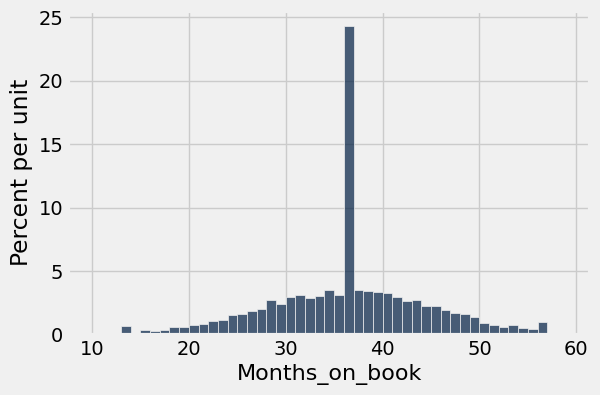

In [ ]:
churn_data.hist("Months_on_book", bins = np.arange(10,60))


In [ ]:
print(max(churn_data.column("Months_on_book")))
print(min(churn_data.column("Months_on_book")))

56
13


In [ ]:
churn_data.group("Months_on_book").sort("count",descending=True)

Months_on_book,count
36,2463
37,358
34,353
38,347
39,341
40,333
31,318
35,317
33,305
30,300


Total_Relationship_Count,count
1,910
2,1243
3,2305
4,1912
5,1891
6,1866


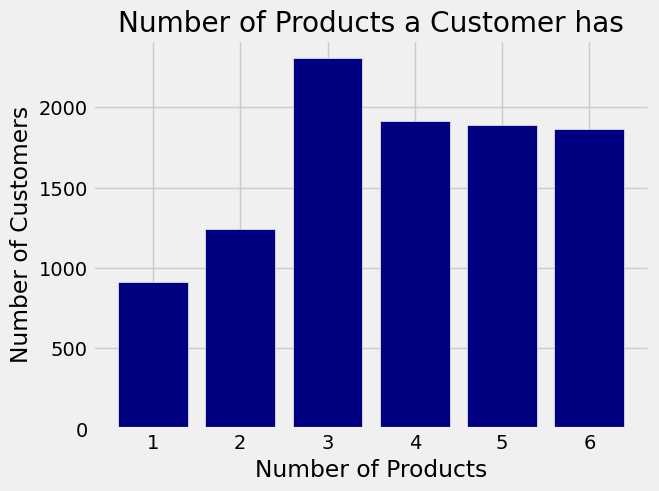

In [ ]:
grouped = churn_data.group("Total_Relationship_Count")
plots.bar(np.arange(1,7,1), grouped.column("count"), color = 'navy', width = 0.8)
plots.title("Number of Products a Customer has")
plots.ylabel("Number of Customers")
plots.xlabel("Number of Products")
grouped

In [ ]:
def print_stats(col_name):
  '''returns calculations for a given column in churn_data'''
  print("mean:", np.mean(churn_data.column(col_name)))
  print("median: ", percentile(50, churn_data.column(col_name)))
  print("mode: ", churn_data.group(col_name).sort("count", descending=True).column(col_name).item(0))
  print("std dev: ", np.std(churn_data.column(col_name)))
  print("std dev: ", np.std(churn_data.column(col_name)))
  print("min: ", min(churn_data.column(col_name)))
  print("max: ", max(churn_data.column(col_name)))
  print("range: ", max(churn_data.column(col_name))-min(churn_data.column(col_name)))
  print("prop 3s: ", churn_data.where("Total_Relationship_Count", are.equal_to(3)).num_rows/churn_data.num_rows)

print_stats("Total_Relationship_Count")

mean: 3.81258023107
median:  4
mode:  3
std dev:  1.55433111772
std dev:  1.55433111772
min:  1
max:  6
range:  5
prop 3s:  0.22760936111385405


Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn Status,Churn Num


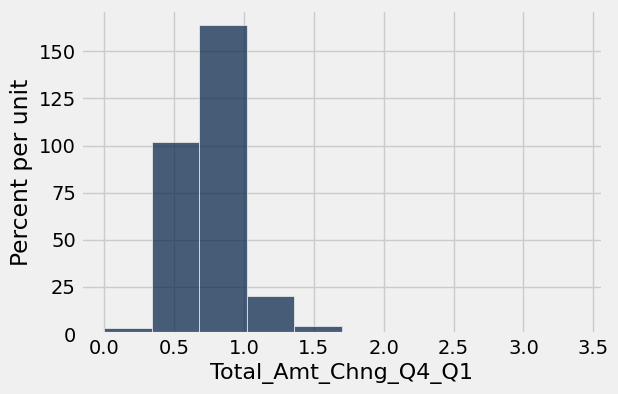

In [ ]:
churn_data.hist("Total_Amt_Chng_Q4_Q1")
churn_data.where("Total_Amt_Chng_Q4_Q1", are.below(0))

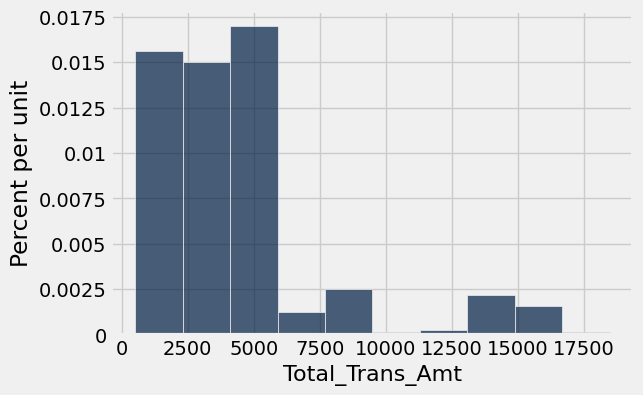

In [ ]:
churn_data.hist("Total_Trans_Amt")

In [ ]:
churn_data.group("Education_Level")

Education_Level,count
College,1013
Doctorate,451
Graduate,3128
High School,2013
Post-Graduate,516
Uneducated,1487
Unknown,1519


In [ ]:
churn_data.group("Marital_Status")

Marital_Status,count
Divorced,748
Married,4687
Single,3943
Unknown,749


In [ ]:
churn_data.group("Income_Category")

Income_Category,count
$120K +,727
$40K - $60K,1790
$60K - $80K,1402
$80K - $120K,1535
Less than $40K,3561
Unknown,1112


0.35163424508739016


Income Group,count
$40K-,3561
$40K-$60K,1790
$60K-$80K,1402
$80K-$120K,1535
$120K+,727


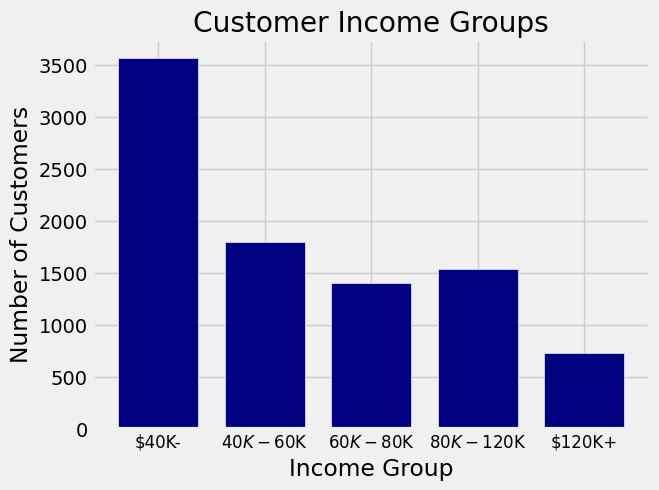

In [ ]:
#reorder to sort categories

sorted_income = Table().with_columns("Income Group",["$40K-", "$40K-$60K", "$60K-$80K", "$80K-$120K", "$120K+"], "count", [3561, 1790, 1402, 1535,727])

labels = sorted_income.column("Income Group")
ind = 2*np.arange(len(labels))


plots.bar(ind, sorted_income.column("count"),  color = 'navy', width=1.5)
plots.xticks(ind, labels, fontsize = 12)
plots.title("Customer Income Groups")
plots.xlabel("Income Group")
plots.ylabel("Number of Customers")

percent_lowest = 3561/10127
print(percent_lowest)
sorted_income


## Deeper Analysis into Number of Products and Income Categories

In [ ]:
cut_churn = churn_data.select("Income_Category", "Total_Relationship_Count", "Churn Status")

def collect(array):
  return array

grouped_cut_churn = cut_churn.group("Income_Category", collect)

grouped_cut_churn

Income_Category,Total_Relationship_Count collect,Churn Status collect
$120K +,[6 5 4 1 2 4 3 6 4 5 3 6 6 6 3 2 6 6 3 6 3 3 2 5 4 5 3 4 ...,[False False False True False False False False False F ...
$40K - $60K,"[3 6 2 ..., 3 4 4]","[False False False ..., False True True]"
$60K - $80K,"[5 5 2 ..., 6 2 5]","[False False False ..., False True False]"
$80K - $120K,"[4 6 3 ..., 1 6 6]","[False False False ..., False False True]"
Less than $40K,"[6 3 5 ..., 4 5 6]","[False False False ..., False True True]"
Unknown,"[6 5 5 ..., 4 1 4]","[False False True ..., False True True]"


In [ ]:
#getting averages and proportions for both categories for each income category (excluding unknown)

for i in np.arange(grouped_cut_churn.num_rows-1):
  row = grouped_cut_churn.row(i)
  relationships = row.item(1) #relationship count
  ones = 0
  twos = 0
  threes = 0
  fours = 0
  fives = 0
  sixes = 0
  other = 0 #just in case
  total = len(relationships)
  for j in relationships:
    if j == 1:
      ones+=1
    elif j == 2:
      twos+=1
    elif j == 3:
      threes+=1
    elif j == 4:
      fours+=1
    elif j == 5:
      fives+=1
    elif j == 6:
      sixes+=1
    else:
      other+=1
  print("Of ", total, " customers in the ", grouped_cut_churn.column(0).item(i), " category, here are the proportion of products each customer has: ")
  print("1: ", ones/total, " 2: ", twos/total, " 3: ", threes/total, " 4: ", fours/total, " 5: ", fives/total, " 6: ", sixes/total)
  print("The average products each customers owns in the ", grouped_cut_churn.column(0).item(i), " category is ", np.mean(relationships))
  print()


Of  727  customers in the  $120K +  category, here are the proportion of products each customer has: 
1:  0.08803301237964237  2:  0.14580467675378267  3:  0.21595598349381018  4:  0.18844566712517194  5:  0.1733149931224209  6:  0.18844566712517194
The average products each customers owns in the  $120K +  category is  3.77854195323

Of  1790  customers in the  $40K - $60K  category, here are the proportion of products each customer has: 
1:  0.0888268156424581  2:  0.1318435754189944  3:  0.23016759776536314  4:  0.17988826815642459  5:  0.19497206703910613  6:  0.17430167597765364
The average products each customers owns in the  $40K - $60K  category is  3.78324022346

Of  1402  customers in the  $60K - $80K  category, here are the proportion of products each customer has: 
1:  0.0884450784593438  2:  0.11697574893009986  3:  0.2225392296718973  4:  0.19900142653352354  5:  0.19044222539229672  6:  0.1825962910128388
The average products each customers owns in the  $60K - $80K  categ

In [ ]:
#now for churn
for i in np.arange(grouped_cut_churn.num_rows-1):
  row = grouped_cut_churn.row(i)
  churn = row.item(2) #churn status
  true = 0
  false = 0
  other = 0 #just in case
  total = len(churn)
  for j in churn:
    if j == True:
      true+=1
    if j == False:
      false+=1
    else:
      other+=1
  print("Of ", total, " customers in the ", grouped_cut_churn.column(0).item(i), " category, here are the proportions of those who churned: ")
  print("Churned (True): ", true/total, " Retained (False): ", false/total)
  print()

Of  727  customers in the  $120K +  category, here are the proportions of those who churned: 
Churned (True):  0.1733149931224209  Retained (False):  0.8266850068775791

Of  1790  customers in the  $40K - $60K  category, here are the proportions of those who churned: 
Churned (True):  0.15139664804469274  Retained (False):  0.8486033519553072

Of  1402  customers in the  $60K - $80K  category, here are the proportions of those who churned: 
Churned (True):  0.13480741797432239  Retained (False):  0.8651925820256776

Of  1535  customers in the  $80K - $120K  category, here are the proportions of those who churned: 
Churned (True):  0.15765472312703582  Retained (False):  0.8423452768729641

Of  3561  customers in the  Less than $40K  category, here are the proportions of those who churned: 
Churned (True):  0.17186183656276327  Retained (False):  0.8281381634372368



In [ ]:
#an easier visualization of the averages of each category

#variation of earlier churn proportions to fit the apply format
def churn_prop(array):
  true = 0
  false = 0
  other = 0 #just in case
  total = len(array)
  for j in array:
    if j == True:
      true+=1
    if j == False:
      false+=1
    else:
      other+=1
  return(true/total)

income_relation = cut_churn.drop("Churn Status").group("Income_Category", np.mean)
relation = income_relation.column(1)
income_churn = cut_churn.drop("Total_Relationship_Count").group("Income_Category", churn_prop)
income = income_churn.column(1)


need_rename = income_relation.join("Income_Category", income_churn)
need_rename = need_rename.with_columns("Mean Product Count", relation, "Churn Proportion", income)

need_rename = need_rename.drop("Total_Relationship_Count mean", "Churn Status churn_prop")
need_rename


Income_Category,Mean Product Count,Churn Proportion
$120K +,3.77854,0.173315
$40K - $60K,3.78324,0.151397
$60K - $80K,3.83381,0.134807
$80K - $120K,3.81694,0.157655
Less than $40K,3.82336,0.171862
Unknown,3.81475,0.168165


# Week 3: Testing


## Hypothesis testing


In [ ]:
obs_proportion = 0.134807

churned = np.count_nonzero(churn_data.column("Churn Status"))
retained = churn_data.num_rows - churned

proportions = make_array(churned/churn_data.num_rows, retained/churn_data.num_rows)
proportions

array([ 0.16065962,  0.83934038])

0.0

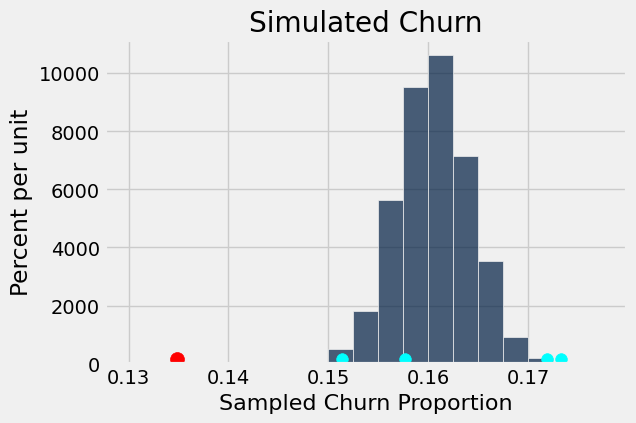

In [ ]:

results = make_array()
reps = 10000

for i in np.arange(reps):
  sim = sample_proportions(churn_data.num_rows, proportions)
  results = np.append(results, sim.item(0))

results_table = Table().with_column("Sampled Churn Proportion", results)
results_table.hist("Sampled Churn Proportion", bins = np.arange(0.13,0.18,0.0025))
plots.scatter(obs_proportion,1.5, color='red', s=100);
plots.scatter(0.173315,1.5, color='cyan', s=70);
plots.scatter(0.151397,1.5, color='cyan', s=70);
plots.scatter(0.157655,1.5, color='cyan', s=70);
plots.scatter(0.171862,1.5, color='cyan', s=70);

plots.title("Simulated Churn")

p_value = 100*np.count_nonzero(results < obs_proportion)/reps
p_value

## AB Testing

In [ ]:
avg_products = np.mean(churn_data.column("Total_Relationship_Count"))
avg_products

3.8125802310654686

In [ ]:
above = churn_data.where("Total_Relationship_Count", are.above(3))
below = churn_data.where("Total_Relationship_Count", are.below_or_equal_to(3))

obs_diff = np.mean(above.column("Churn Status")) - np.mean(below.column("Churn Status"))
obs_diff

-0.10529933007555038

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

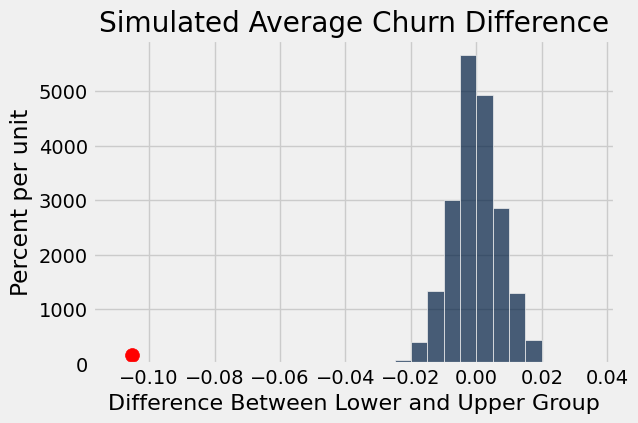

In [ ]:
# let's take a in depth look at our $60-80K group again. of the two factors that could've contributed to lower churn rates,
# only relationship count is quanntifiable. the group's average product is 3.83381 which lies above the data set's average products of 3.81258
# let's split the group into above average and below average to form two groups for AB testing. predict the avg churn for A (above 3) < B (3 and below)

ab_results = make_array()
reps = 1000

size_A = churn_data.where("Total_Relationship_Count", are.above(3)).num_rows
size_B = churn_data.where("Total_Relationship_Count", are.below_or_equal_to(3)).num_rows

for i in np.arange(reps):
  print(i)
  shuffled = churn_data.select("Total_Relationship_Count", "Churn Status").sample(with_replacement=False)

  a = shuffled.take(np.arange(0, size_A))
  b = shuffled.take(np.arange(size_A, size_A + size_B))

  churn_A = np.mean(a.column("Churn Status"))
  churn_B = np.mean(b.column("Churn Status"))

  ab_results = np.append(ab_results, churn_B - churn_A)

tbl = Table().with_column("Difference Between Lower and Upper Group", ab_results)
tbl.hist("Difference Between Lower and Upper Group", bins = np.arange(-0.11,0.04, 0.005))
plots.title("Simulated Average Churn Difference")
plots.scatter(obs_diff,1.5, color='red', s=100);

In [ ]:
# ab_p_value = 100*np.count_nonzero(ab_results < obs_diff)/reps
# ab_p_value

#Week 4: Confidence Intervals

## Choosing a quantities to estimate:
Observation: Customers who churned used their cards less. Meaning fewer transactions, lower transaction amounts, less revolving balance (don't want to pay more to the bank w/ interest), lower utilization ration. In general, spending less on the to-be churned card.

For both: Bootstrap churned population, since we don't have that much data for that group.

Quantitative: Difference between churned average transaction amount (total transaction amount/number of transactions) and the population average transaction amount. See if confidence interval includes 0, meaning no significant difference.

Categorical: Proportion of the churned population that has below population average total revolving balance.


In [ ]:
#Quantitative

count_results = make_array()
amt_results = make_array()
reps = 1000

churn_stripped = churn_data.where("Churn Status", are.equal_to(True)).select("Total_Trans_Amt", "Total_Trans_Ct")

pop_trans_count = np.mean(churn_data.column("Total_Trans_Ct"))
pop_trans_amt = np.mean(churn_data.column("Total_Trans_Amt"))

for i in np.arange(reps):
  bootstrap = churn_stripped.sample()

  sample_trans_count = np.mean(bootstrap.column("Total_Trans_Ct"))
  sample_trans_amt = np.mean(bootstrap.column("Total_Trans_Amt"))

  count_diff = sample_trans_count - pop_trans_count
  amt_diff = sample_trans_amt - pop_trans_amt

  count_results = np.append(count_results, count_diff)
  amt_results = np.append(amt_results, amt_diff)

In [ ]:
counts_lower = percentile(2.5,count_results)
counts_upper = percentile(97.5, count_results)

amt_lower = percentile(2.5,amt_results)
amt_upper = percentile(97.5, amt_results)

Count CI:  [-20.62267736926043, -19.282788002327422]
Amount CI:  [-1410.787594659078, -1201.3186333806511]


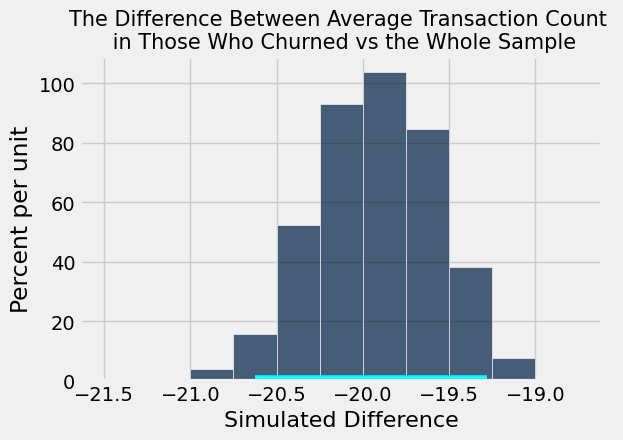

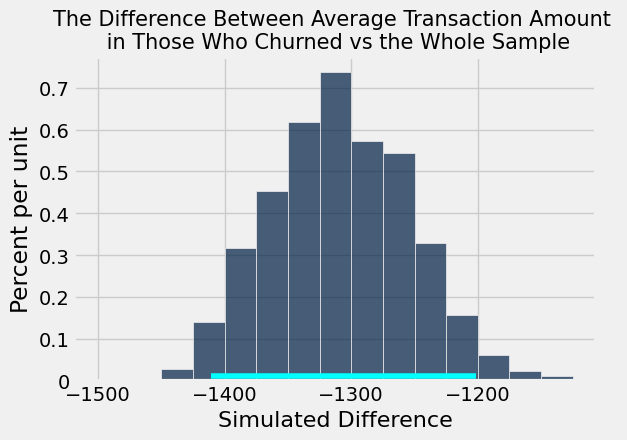

In [ ]:
count_tbl = Table().with_column("Simulated Difference", count_results)
count_tbl.hist("Simulated Difference", bins = np.arange(-21.5,-18.5,0.25))
plots.title("The Difference Between Average Transaction Count \n in Those Who Churned vs the Whole Sample", fontsize = 15);
plots.plot([counts_lower, counts_upper], [0.01, 0.01], color = 'cyan')

amt_tbl = Table().with_column("Simulated Difference", amt_results)
amt_tbl.hist("Simulated Difference", bins = np.arange(-1500,-1100,25))
plots.title("The Difference Between Average Transaction Amount \n in Those Who Churned vs the Whole Sample", fontsize = 15);
plots.plot([amt_lower, amt_upper], [0.0001, 0.0001], color = 'cyan')

print("Count CI: ", [counts_lower, counts_upper])
print("Amount CI: ", [amt_lower, amt_upper])

In [ ]:
#Qualitative - Proportion of the churned population that has below population average total revolving balance.

revolve_results = make_array()
reps = 1000

churn_stripped = churn_data.where("Churn Status", are.equal_to(True)).select("Total_Revolving_Bal")

pop_avg_revolve = np.mean(churn_data.column("Total_Revolving_Bal"))

for i in np.arange(reps):
  bootstrap = churn_stripped.sample()

  below_avg = bootstrap.where("Total_Revolving_Bal", are.below(pop_avg_revolve)).num_rows

  churn_prop = below_avg/churn_stripped.num_rows

  revolve_results = np.append(revolve_results, churn_prop)

Revolve CI:  [0.71542716656422867, 0.75722188076213892]


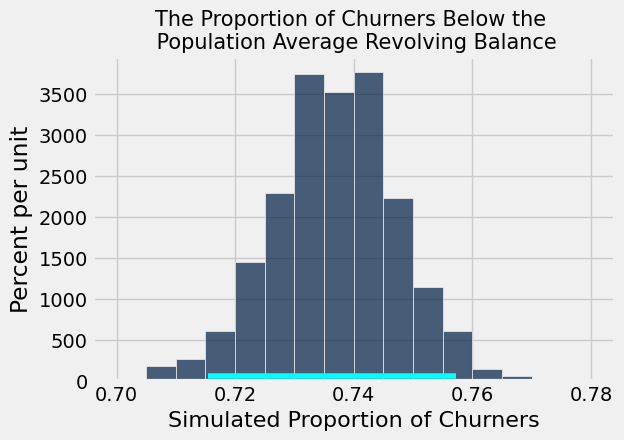

In [ ]:
revolve_lower = percentile(2.5, revolve_results)
revolve_upper = percentile(97.5, revolve_results)

revolve_tbl = Table().with_column("Simulated Proportion of Churners", revolve_results)
revolve_tbl.hist("Simulated Proportion of Churners", bins = np.arange(0.7,0.78,0.005))
plots.title("The Proportion of Churners Below the \n Population Average Revolving Balance", fontsize = 15);
plots.plot([revolve_lower, revolve_upper], [0.5, 0.5], color = 'cyan')

print("Revolve CI: ", [revolve_lower, revolve_upper])

# Week 5: Linear Regression & Prediction

In [ ]:
churn_data.scatter("Credit_Limit", "Avg_Utilization_Ratio", label = "non churners", s=5, color="steelblue")
churners = churn_data.where("Churn Status", are.equal_to(True))
plots.scatter(churners.column("Credit_Limit"), churners.column("Avg_Utilization_Ratio"), label = "churners", color = "fuchsia", s=5)
plots.legend(bbox_to_anchor=(0.5,.8));
plots.title("Credit Limit vs Avg Utilization \n Ratio with a Linear Line of Best Fit")
plots.xlabel("Credit Limit")
plots.ylabel("Average Utilization Ratio")

In [ ]:
#Seems like there is a correlation (though not linear)

util_ratio = churn_data.column("Avg_Utilization_Ratio")
cred_limit = churn_data.column("Credit_Limit")

SU_ratio = (util_ratio - np.mean(util_ratio))/np.std(util_ratio)
SU_limit = (cred_limit - np.mean(cred_limit))/np.std(cred_limit)

r = np.mean(SU_ratio * SU_limit)

#find line of best fit

slope = r*np.std(util_ratio)/np.std(cred_limit)
intercept = np.mean(util_ratio) - (slope*np.mean(cred_limit))

print("R-value: ", r)

In [ ]:
#making predictions to plot line of best fit

churn_data.scatter("Credit_Limit", "Avg_Utilization_Ratio", label = "non churners", s=5, color="steelblue")
churners = churn_data.where("Churn Status", are.equal_to(True))
plots.scatter(churners.column("Credit_Limit"), churners.column("Avg_Utilization_Ratio"), label = "churners", color = "fuchsia", s=5)
plots.legend(bbox_to_anchor=(0.5,.8));

x_min = min(cred_limit)
x_max = max(cred_limit)
pred_y_min = slope*x_min + intercept
pred_y_max = slope*x_max + intercept
plots.plot([x_min, x_max],[pred_y_min, pred_y_max], color='red', linewidth=3);

plots.title("Credit Limit vs Avg Utilization \n Ratio with a Linear Line of Best Fit")
plots.xlabel("Credit Limit")
plots.ylabel("Average Utilization Ratio")

print("slope: ", slope, "intercept: ", intercept)

In [ ]:
#doesn't look super great, so lets use the minimize function to find a better line of best fit

predictions = (slope*cred_limit) + intercept
residuals = util_ratio - predictions
rmse = np.sqrt(np.mean(residuals**2))

def calc_rmse(slope, intercept):
  predictions = (slope*cred_limit) + intercept
  residuals = util_ratio - predictions
  rmse = np.sqrt(np.mean(residuals**2))
  return rmse

final = minimize(calc_rmse)
new_slope = final.item(0)
new_int = final.item(1)

print('Using equations we got slope',slope,'and y intercept',intercept)
print('Using minimization we got slope',new_slope,'and y intercept',new_int)
print("Linear RMSE: ", rmse)

In [ ]:
#lets linearize our data using a log-log scale

churn_data_2 = churn_data.with_columns('CL Log', np.log(churn_data.column('Credit_Limit')), 'AUR Log', np.log(churn_data.column('Avg_Utilization_Ratio')))
churn_data_2.scatter("CL Log", "AUR Log", label = "non churners", s=5, color="steelblue")

plots.title("Log Credit Limit vs Log Avg Utilization Ratio")
plots.xlabel("Log Credit Limit")
plots.ylabel("Log Average Utilization Ratio")

In [ ]:
fixed_log_tbl = churn_data_2.where("AUR Log", are.between(-100,100)).where("CL Log", are.between(-100,100))
log_AUR = fixed_log_tbl.column("AUR Log")
log_CL = fixed_log_tbl.column("CL Log")

SU_AUR = (log_AUR - np.mean(log_AUR))/np.std(log_AUR)
SU_CL = (log_CL - np.mean(log_CL))/np.std(log_CL)

log_r = np.mean(SU_AUR * SU_CL)

#find line of best fit

log_slope = log_r*np.std(log_AUR)/np.std(log_CL)
log_intercept = np.mean(log_AUR) - (log_slope*np.mean(log_CL))

print("log r,", log_r)

In [ ]:
churn_data_2.scatter("CL Log", "AUR Log", label = "non churners", s=5, color="steelblue")
x_min = min(log_CL)
x_max = max(log_CL)
pred_y_min = log_slope*x_min + log_intercept
pred_y_max = log_slope*x_max + log_intercept
plots.plot([x_min, x_max],[pred_y_min, pred_y_max], color='red', linewidth=3);

plots.title("Log Credit Limit vs Log Avg \n Utilization Ratio with a Line of Best Fit")
plots.xlabel("Log Credit Limit")
plots.ylabel("Log Average Utilization Ratio")

print("slope: ", log_slope, "intercept: ", log_intercept)

In [ ]:
churn_data_nonzero = churn_data.where("Avg_Utilization_Ratio", are.not_equal_to(0)).where("Credit_Limit", are.not_equal_to(0))

churn_data_nonzero.scatter("Credit_Limit", "Avg_Utilization_Ratio", label = "non churners", s=5, color="steelblue")
churners = churn_data_nonzero.where("Churn Status", are.equal_to(True))
plots.scatter(churners.column("Credit_Limit"), churners.column("Avg_Utilization_Ratio"), label = "churners", color = "fuchsia", s=5)
plots.legend(bbox_to_anchor=(0.5,.8));

x_val = np.arange(1350,35000,1)
y_val = (np.e**log_intercept)*(x_val**log_slope)

plots.plot(x_val,y_val, color='red', linewidth=3);

plots.title("Credit Limit vs Avg Utilization Ratio \n with a Logarithmic Line of Best Fit")
plots.ylabel("Average Utilization Ratio")
plots.xlabel("Credit Limit")

nonzero_AUR = churn_data_nonzero.column("Avg_Utilization_Ratio")
nonzero_CL = churn_data_nonzero.column("Credit_Limit")

log_predictions = (np.e**log_intercept)*(nonzero_CL**log_slope)
log_residuals = nonzero_AUR - log_predictions
log_rmse = np.sqrt(np.mean(log_residuals**2))
print("Log RMSE:", log_rmse)

In [ ]:
#our log-log rmse isn't that different, maybe due to the exclusion of zero values
#so let's run linear regression on a non-zero data set!

SU_nonzero_AUR = (nonzero_AUR - np.mean(nonzero_AUR))/np.std(nonzero_AUR)
SU_nonzero_CL = (nonzero_CL - np.mean(nonzero_CL))/np.std(nonzero_CL)

nonzero_linear_r = np.mean(SU_nonzero_AUR * SU_nonzero_CL)

#find line of best fit

nonzero_linear_slope = nonzero_linear_r*np.std(nonzero_AUR)/np.std(nonzero_CL)
nonzero_linear_intercept = np.mean(nonzero_AUR) - (nonzero_linear_slope*np.mean(nonzero_CL))

linear_predictions = (nonzero_linear_slope*nonzero_CL) + nonzero_linear_intercept
linear_residuals = nonzero_AUR - linear_predictions
nonzero_linear_rmse = np.sqrt(np.mean(linear_residuals**2))

print("nonzero linear RMSE: ", nonzero_linear_rmse)


In [ ]:
#it's interesting to note that there is a cluster of churners who have a lower than expected average
#explore more??


# Week 6: Logistic Regression

Single Variable Logistic Regression (binary classification)
Resources taken from InspiritAI online ML course

In [ ]:
#let's use number of relations as the first variable as we previously determined that it is an indicator of churn (more products = retention, fewer = churn)
#to use ML, we need to split our data into a training set and a testing set

churn_df = churn_data.select("Avg_Utilization_Ratio", "Churn Num").to_df()
train_set, test_set = train_test_split(churn_df, test_size = 0.2, random_state = 1)

#input is the number of products, output is the churn status

X = ['Avg_Utilization_Ratio']
y = 'Churn Num'

X_train = train_set[X]
print('X_train, our input variables:')
print(X_train.head())
print()

y_train = train_set[y]
print('y_train, our output variable:')
print(y_train.head())

In [ ]:
#creating a 'logreg_model' object that handles the line fitting
logreg_model = linear_model.LogisticRegression()
logreg_model.fit(X_train, y_train)

In [ ]:
#see if it worked, use our test data to compare
X_test = test_set[X]
y_test = test_set[y]

y_pred = logreg_model.predict(X_test)

test_set['predicted'] = y_pred
sns.catplot(x = 'Avg_Utilization_Ratio', y = 'Churn Num', hue = 'predicted', data=test_set).set(title='Single Variable Logistic Regression Predictions', xlabel='Avg Utilization Ratio', ylabel='Churn Status ')

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

In [ ]:
#adding more variables to our model

churn_data.sample(churn_data.num_rows)
churn_df = churn_data.select("Credit_Limit", "Total_Revolving_Bal", "Total_Trans_Amt", "Total_Trans_Ct", "Avg_Utilization_Ratio", "Churn Num").to_df()
train_set, test_set = train_test_split(churn_df, test_size = 0.2, random_state = 1)

#input is the number of products, output is the churn status

X = ["Credit_Limit", "Total_Revolving_Bal", "Total_Trans_Amt", "Total_Trans_Ct", "Avg_Utilization_Ratio"]
y = 'Churn Num'

X_train = train_set[X]
print('X_train, our input variables:')
print(X_train.head())
print()

y_train = train_set[y]
print('y_train, our output variable:')
print(y_train.head())

In [ ]:
X_test = test_set[X]
y_test = test_set[y]

multi_model = linear_model.LogisticRegression()
multi_model.fit(X_train,y_train)
pred = multi_model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(accuracy)